# 09 · The conformal decision layer (Step 11)

**Goal:** turn each probability into **approve / refer / decline** with a guarantee: at most about
α of real defaulters are auto-approved, and at most about α of good customers are auto-declined.
Everyone the model is unsure about is referred to a human.

- **A. The cut-offs:** one per class (Mondrian conformal), from the **conformal split** only.
- **B. Does the guarantee hold?** 100 random half-splits of the conformal split (cut-offs from one
  half, checked on the other), then the validation split. Compared with one cut-off for everyone.
- **C. The price of the guarantee:** the approve / refer / decline shares as α changes.
- **D. Conformal vs the Step 10 money rule.**

**Data rules:** the cut-offs use only the conformal split. The validation split is a fair check
here because Step 10 kept the raw model (no calibrator was fitted on it). The test split stays
locked until Step 15.

**Time:** under a minute.

**Saved results:**

- `reports/results_step11_coverage.csv`, `reports/results_step11_alpha.csv`
- `reports/figures/fig23_conformal_coverage.png`, `fig24_decisions_vs_alpha.png`
- the cut-offs, added to `models/decision.json`

In [1]:
%load_ext autoreload
%autoreload 2

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.decision.conformal import class_cutoffs, conformal_quantile, coverage, decide
from creditrisk.features.build import load_features
from creditrisk.models.data import get_xy
from creditrisk.models.final import MODEL_DIR, load_final_model

SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
ALPHA = 0.10
facts = {}

_, details = load_final_model()
model = joblib.load(MODEL_DIR / "calibrated_final.joblib")   # Step 10's choice (here: the raw model)
decision = json.loads((MODEL_DIR / "decision.json").read_text())
features = load_features()
splits = load_splits()
X_conf, y_conf, _, _ = get_xy(features, splits, "conformal")
X_val, y_val, _, _ = get_xy(features, splits, "valid")
p_conf = model.predict_proba(X_conf[details["features"]])[:, 1]
p_val = model.predict_proba(X_val[details["features"]])[:, 1]
print(f"conformal split: {len(y_conf):,} applicants ({y_conf.sum():,} defaulters) | "
      f"validation: {len(y_val):,} | Step 10 calibration: {decision['calibration']}")


def one_cutoff(p, y, alpha):
    """Standard conformal: one cut-off over everyone's score for their true label."""
    q = conformal_quantile(np.where(y == 1, 1 - p, p), alpha)
    return q, q


def summary(p, y, q_repay, q_default):
    """Coverage per class, the two guaranteed error rates, and the decision shares."""
    d = decide(p, q_repay, q_default)
    cov = coverage(p, y, q_repay, q_default)
    return {"coverage repay": cov["repay"], "coverage default": cov["default"],
            "defaulters auto-approved": np.mean(d[y == 1] == "approve"),
            "good customers auto-declined": np.mean(d[y == 0] == "decline"),
            **{f"share {k}": np.mean(d == k) for k in ("approve", "refer", "decline")}}

conformal split: 30,751 applicants (2,483 defaulters) | validation: 30,751 | Step 10 calibration: none


## A. The cut-offs (α = 10%)

Score for "repay" = p, score for "default" = 1 − p. Each class's cut-off is the
⌈(n + 1)(1 − α)⌉-th smallest score among the applicants with that true label.

In [2]:
q_repay, q_default = class_cutoffs(p_conf, y_conf, ALPHA)
q_one = one_cutoff(p_conf, y_conf, ALPHA)[0]
print(f"one cut-off per class: 'repay' kept if p <= {q_repay:.4f}; "
      f"'default' kept if p >= {1 - q_default:.4f}")
print(f"  -> approve if p < {1 - q_default:.4f}, decline if p > {q_repay:.4f}, refer in between")
print(f"one cut-off for everyone: q = {q_one:.4f} -> 'default' kept only if p >= {1 - q_one:.4f}")
facts["cutoffs"] = {"q_repay": round(q_repay, 4), "q_default": round(q_default, 4),
                    "approve_below": round(1 - q_default, 4), "decline_above": round(q_repay, 4),
                    "one_cutoff_q": round(q_one, 4)}

one cut-off per class: 'repay' kept if p <= 0.1655; 'default' kept if p >= 0.0355
  -> approve if p < 0.0355, decline if p > 0.1655, refer in between
one cut-off for everyone: q = 0.3250 -> 'default' kept only if p >= 0.6750


## B. Does the guarantee hold?

The guarantee is about new applicants, so it must be checked on applicants the cut-offs never saw:
fit on a random half of the conformal split, check on the other half, 100 times.

method,one for everyone,one per class,one for everyone (min-max),one per class (min-max)
coverage repay,0.9779,0.9006,0.971-0.983,0.892-0.907
coverage default,0.0106,0.8992,0.004-0.019,0.874-0.933
defaulters auto-approved,0.8246,0.1008,0.796-0.857,0.067-0.126
good customers auto-declined,0.0001,0.0994,0.000-0.000,0.093-0.108
share approve,0.9655,0.4010,0.958-0.972,0.367-0.430
share refer,0.0335,0.4723,0.027-0.042,0.444-0.508
share decline,0.0010,0.1267,0.000-0.002,0.121-0.135


validation split, cut-offs from the whole conformal split:


,one per class,one for everyone
coverage repay,0.9015,0.9796
coverage default,0.9069,0.0085
defaulters auto-approved,0.0931,0.8280
good customers auto-declined,0.0985,0.0002
share approve,0.4024,0.9674
share refer,0.4709,0.0318
share decline,0.1267,0.0008


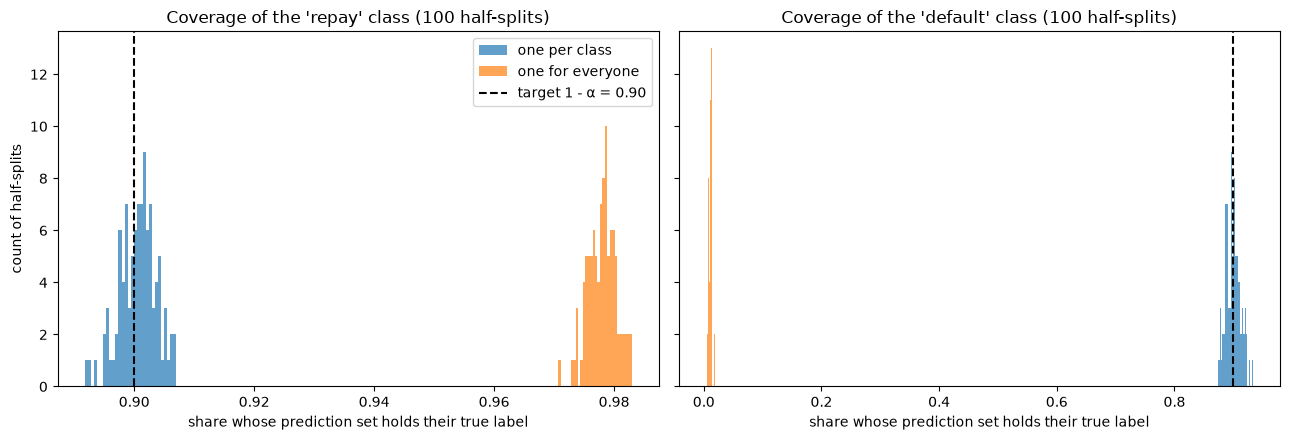

In [3]:
rng = np.random.default_rng(SEED)
rows = []
for r in range(100):
    half = rng.random(len(y_conf)) < 0.5
    for method, cut in [("one per class", class_cutoffs), ("one for everyone", one_cutoff)]:
        qr, qd = cut(p_conf[half], y_conf[half], ALPHA)
        rows.append({"method": method, "repeat": r,
                     **summary(p_conf[~half], y_conf[~half], qr, qd)})
repeats = pd.DataFrame(rows)
cols = ["coverage repay", "coverage default", "defaulters auto-approved",
        "good customers auto-declined", "share approve", "share refer", "share decline"]
by_method = repeats.groupby("method")[cols]
table = by_method.mean().round(4).T
for m in table.columns:
    table[f"{m} (min-max)"] = [f"{lo:.3f}-{hi:.3f}" for lo, hi in
                              zip(by_method.min().loc[m], by_method.max().loc[m])]
display(table)

val = pd.DataFrame({
    "one per class": summary(p_val, y_val, q_repay, q_default),
    "one for everyone": summary(p_val, y_val, q_one, q_one),
}).round(4)
print("validation split, cut-offs from the whole conformal split:")
display(val)
pd.concat({"half-splits (mean)": table[["one per class", "one for everyone"]],
           "validation": val}, axis=1).to_csv(REPORTS / "results_step11_coverage.csv")
facts["half_splits_mean"] = table[["one per class", "one for everyone"]].to_dict()
facts["validation"] = val.to_dict()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, cls in zip(axes, ["repay", "default"]):
    for m in ("one per class", "one for everyone"):
        ax.hist(repeats.loc[repeats["method"] == m, f"coverage {cls}"], bins=30, alpha=0.7, label=m)
    ax.axvline(1 - ALPHA, color="k", linestyle="--", label=f"target 1 - α = {1 - ALPHA:.2f}")
    ax.set(title=f"Coverage of the '{cls}' class (100 half-splits)",
           xlabel="share whose prediction set holds their true label")
axes[0].set_ylabel("count of half-splits")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "fig23_conformal_coverage.png", dpi=150)
plt.show()

## C. The price of the guarantee

A smaller α means a stronger promise, and so more applicants referred to a human.
Cut-offs from the whole conformal split, decisions on the validation split.

,coverage repay,coverage default,defaulters auto-approved,good customers auto-declined,share approve,share refer,share decline
alpha,,,,,,,
0.02,0.9816,0.9750,0.0250,0.0184,0.1713,0.7989,0.0298
0.04,0.9612,0.9577,0.0423,0.0388,0.2488,0.6942,0.0571
0.06,0.9410,0.9384,0.0616,0.0590,0.3086,0.6102,0.0812
0.08,0.9210,0.9255,0.0745,0.0790,0.3552,0.5399,0.1049
0.10,0.9015,0.9069,0.0931,0.0985,0.4024,0.4709,0.1267
0.12,0.8813,0.8880,0.1120,0.1187,0.4440,0.4072,0.1488
0.14,0.8637,0.8715,0.1285,0.1363,0.4890,0.3434,0.1676
0.16,0.8424,0.8529,0.1471,0.1576,0.5261,0.2839,0.1899
0.18,0.8240,0.8352,0.1648,0.1760,0.5522,0.2388,0.2089


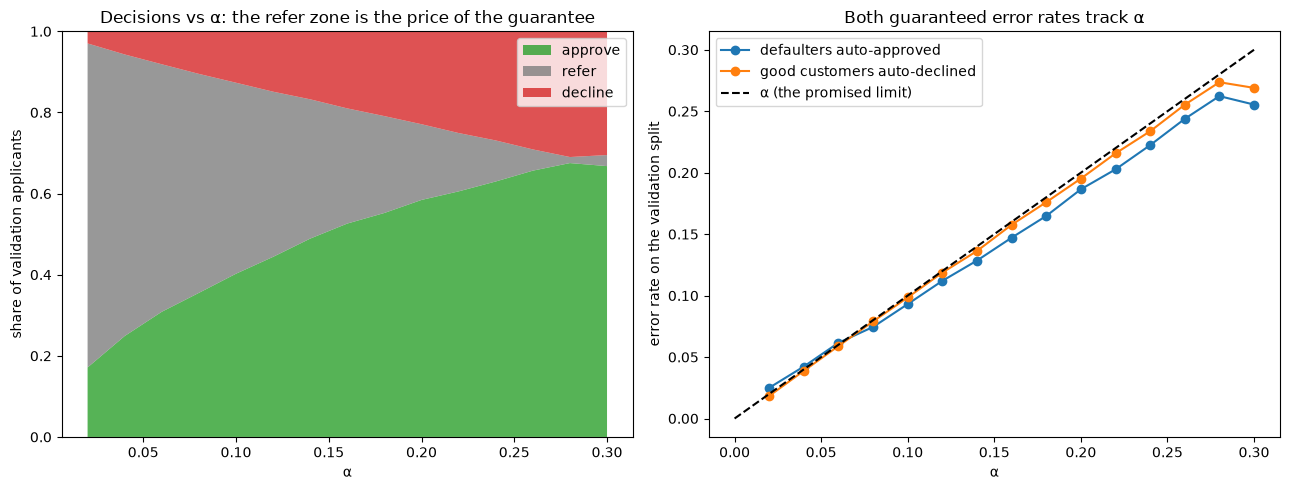

In [4]:
alphas = np.round(np.arange(0.02, 0.301, 0.02), 2)
sweep = pd.DataFrame([{"alpha": a, **summary(p_val, y_val, *class_cutoffs(p_conf, y_conf, a))}
                      for a in alphas]).set_index("alpha").round(4)
display(sweep)
sweep.to_csv(REPORTS / "results_step11_alpha.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.stackplot(sweep.index, sweep["share approve"], sweep["share refer"], sweep["share decline"],
              labels=["approve", "refer", "decline"], colors=["C2", "C7", "C3"], alpha=0.8)
ax1.set(xlabel="α", ylabel="share of validation applicants", ylim=(0, 1),
        title="Decisions vs α: the refer zone is the price of the guarantee")
ax1.legend(loc="upper right")
ax2.plot(sweep.index, sweep["defaulters auto-approved"], marker="o", label="defaulters auto-approved")
ax2.plot(sweep.index, sweep["good customers auto-declined"], marker="o",
         label="good customers auto-declined")
ax2.plot([0, 0.3], [0, 0.3], "k--", label="α (the promised limit)")
ax2.set(xlabel="α", ylabel="error rate on the validation split",
        title="Both guaranteed error rates track α")
ax2.legend()
fig.tight_layout()
fig.savefig(FIG / "fig24_decisions_vs_alpha.png", dpi=150)
plt.show()
facts["auto_decided_at"] = {a: round(1 - float(sweep.loc[a, "share refer"]), 4)
                            for a in (0.05, 0.1, 0.2) if a in sweep.index}

## D. Conformal vs the Step 10 money rule

The money rule approves everyone below the break-even probability; the conformal layer only
auto-decides where it can keep its promise. Default rate in each group (validation split):

In [5]:
conf_d = decide(p_val, q_repay, q_default)
money_d = np.where(p_val < decision["threshold"], "approve", "decline")
cross = pd.crosstab(pd.Series(conf_d, name="conformal"), pd.Series(money_d, name="money rule"),
                    normalize="all").round(4)
display(cross)
rates = pd.DataFrame({"share": pd.Series(conf_d).value_counts(normalize=True),
                      "default rate": pd.Series(y_val).groupby(conf_d).mean()}).round(4)
display(rates)
facts["default_rate_by_decision"] = rates["default rate"].to_dict()
facts["conformal_vs_money"] = cross.to_dict()

money rule,approve,decline
conformal,,
approve,0.4024,0.0000
decline,0.0011,0.1256
refer,0.4709,0.0000


,share,default rate
approve,0.4024,0.0187
decline,0.1267,0.2856
refer,0.4709,0.0786


## Save for Step 16

In [6]:
decision["conformal"] = {"step": 11, "alpha": ALPHA, "q_repay": q_repay, "q_default": q_default,
                         "approve_below": 1 - q_default, "decline_above": q_repay,
                         "fitted_on": f"conformal split, {len(y_conf):,} rows"}
(MODEL_DIR / "decision.json").write_text(json.dumps(decision, indent=2))
print(json.dumps(decision["conformal"], indent=2))

{
  "step": 11,
  "alpha": 0.1,
  "q_repay": 0.16552342365471562,
  "q_default": 0.9645328635615452,
  "approve_below": 0.03546713643845478,
  "decline_above": 0.16552342365471562,
  "fitted_on": "conformal split, 30,751 rows"
}


In [7]:
for key, value in facts.items():
    print(f"{key}: {value}")

cutoffs: {'q_repay': 0.1655, 'q_default': 0.9645, 'approve_below': 0.0355, 'decline_above': 0.1655, 'one_cutoff_q': 0.325}
half_splits_mean: {'one per class': {'coverage repay': 0.9006, 'coverage default': 0.8992, 'defaulters auto-approved': 0.1008, 'good customers auto-declined': 0.0994, 'share approve': 0.401, 'share refer': 0.4723, 'share decline': 0.1267}, 'one for everyone': {'coverage repay': 0.9779, 'coverage default': 0.0106, 'defaulters auto-approved': 0.8246, 'good customers auto-declined': 0.0001, 'share approve': 0.9655, 'share refer': 0.0335, 'share decline': 0.001}}
validation: {'one per class': {'coverage repay': 0.9015, 'coverage default': 0.9069, 'defaulters auto-approved': 0.0931, 'good customers auto-declined': 0.0985, 'share approve': 0.4024, 'share refer': 0.4709, 'share decline': 0.1267}, 'one for everyone': {'coverage repay': 0.9796, 'coverage default': 0.0085, 'defaulters auto-approved': 0.828, 'good customers auto-declined': 0.0002, 'share approve': 0.9674, 'sh

## Findings

- **Cut-offs (α = 10%, from 30,751 conformal-split applicants, 2,483 of them defaulters):** approve if p < 0.0355, decline if p > 0.1655, refer to a human in between.
- **The guarantee holds:** over 100 half-splits of the conformal split, coverage is 0.901 for repayers (range 0.892 to 0.907) and 0.899 for defaulters (0.874 to 0.933; wider because each half has only about 1,240 defaulters). On the validation split: 0.902 and 0.907, so 9.3% of real defaulters are auto-approved and 9.9% of good customers are auto-declined, both under the promised 10%.
- **One cut-off for everyone fails, as warned:** it still covers 97.8% of repayers, but the "default" label is in the set for only 1.1% of defaulters, so **82% of real defaulters would be auto-approved**. Most defaulters get a low p (the average risk is 8%), so their "default" score almost never clears a cut-off shared with the repayers. This is why the cut-offs must be per class.
- **The price of the guarantee is a big refer zone:** at α = 10%, 40.2% approved, 47.1% referred, 12.7% declined (52.9% decided automatically). At α = 20%, 81.3% are decided automatically; at α = 2%, only 20.1%. With ROC-AUC 0.79 the model cannot separate the middle of the risk range, and conformal says so honestly instead of guessing.
- **Error rates track α:** both stay close to α across the sweep. At α = 2%, 2.5% of defaulters were auto-approved, slightly above the limit: the guarantee is an average over calibration sets, so one finite check can land a little above it. From α = 28% the two cut-offs cross, some sets become empty (referred), and the curves bend down.
- **The three groups really differ:** default rate 1.87% among the approved, 7.86% among the referred (about the average), 28.56% among the declined, 15 times the approved group.
- **Conformal vs the Step 10 money rule:** the decline line (p > 0.1655) is almost the money break-even (0.1667), a coincidence of the m and LGD assumptions; only 0.11% of applicants are declined by conformal but approved by the money rule. The real difference is the middle: the money rule approves all 47% that conformal refers. For the app (Step 16): auto-approve and auto-decline where conformal is sure, and show the money rule as the suggestion for referred applicants.
- **Limitation:** the guarantee assumes new applicants look like the conformal split. The Kaggle test file already differs (contract-type PSI 0.21), so the Step 16 drift monitor should trigger recomputing the cut-offs.
- **Saved:** the cut-offs in `models/decision.json` (`conformal`: α, q_repay, q_default, approve_below, decline_above).